# 21 — GNN-SDM: Selected Species Deep Dive

Train GNN-SDM with the best architecture on 12 selected species:
6 common (habitat diversity) + 6 rare/vulnerable (conservation focus).

**Common species** (from architecture search):
- *Picea abies* — montane forest
- *Fagus sylvatica* — lowland forest
- *Trifolium pratense* — grassland
- *Potentilla erecta* — alpine grassland
- *Phragmites australis* — wetland
- *Senecio inaequidens* — invasive/urban

**Vulnerable species** (conservation-relevant):
- *Cypripedium calceolus* — protected orchid, forest understory
- *Drosera rotundifolia* — carnivorous, bog specialist
- *Pulsatilla vulgaris* — dry grassland, vulnerable
- *Gladiolus palustris* — wetland, endangered (fewest records)
- *Aquilegia alpina* — alpine endemic
- *Stipa pennata* — dry steppe, rare habitat

### Setup and load graph

In [1]:
import config
import numpy as np
import pandas as pd
import pickle
import json
import time
import torch
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import SAGEConv
import networkx as nx

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

# Load graph
with open('landscape_graph.pkl', 'rb') as f:
    G = pickle.load(f)

# Load patch features and names
patch_features = np.load('patch_features.npy')
with open('patch_feature_names.json') as f:
    feature_names = json.load(f)

n_patches = G.number_of_nodes()
n_features = len(feature_names)
print(f'Graph: {n_patches:,} nodes, {G.number_of_edges():,} edges, '
      f'{n_features} features')


/home/sagemaker-user/.conda/envs/cas/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda
GPU: Tesla T4
Graph: 166,464 nodes, 465,833 edges, 12 features


### Convert to PyG Data object

In [2]:
# Node features
X = torch.tensor(patch_features, dtype=torch.float32)

# Normalize features (zero mean, unit variance)
X_mean = X.mean(dim=0)
X_std = X.std(dim=0).clamp(min=1e-6)
X = (X - X_mean) / X_std

# Edge index (PyG format: 2 × n_edges, both directions for undirected)
edges = list(G.edges())
src = [e[0] for e in edges] + [e[1] for e in edges]
dst = [e[1] for e in edges] + [e[0] for e in edges]
edge_index = torch.tensor([src, dst], dtype=torch.long)

# PageRank for presence weighting
print('Computing PageRank...')
pagerank = nx.pagerank(G)
pr_values = torch.tensor([pagerank[i] for i in range(n_patches)], dtype=torch.float32)

print(f'Node features: {X.shape}')
print(f'Edge index: {edge_index.shape}')
print(f'PageRank: min={pr_values.min():.6f}, max={pr_values.max():.6f}')


Computing PageRank...
Node features: torch.Size([166464, 12])
Edge index: torch.Size([2, 931666])
PageRank: min=0.000002, max=0.001098


### Load GBIF and map to patches

In [3]:
import rioxarray
from s3_utils import load_zarr
from rasterio.transform import rowcol

# Patch labels raster for coordinate mapping
patch_labels_da = load_zarr(
    config.S3_PROCESSED + '/patches/patch_labels_30m.zarr',
    name='patch_label',
)
patch_labels = patch_labels_da.values
transform = patch_labels_da.rio.transform()

# GBIF
gbif = pd.read_parquet(config.GBIF_PARQUET, storage_options={'anon': False})

# Vectorized mapping: all records → patch IDs
rows, cols = rowcol(transform, gbif['decimallongitude'].values,
                    gbif['decimallatitude'].values)
rows, cols = np.array(rows), np.array(cols)
h, w = patch_labels.shape
valid = (rows >= 0) & (rows < h) & (cols >= 0) & (cols < w)
gbif_patch_ids = np.full(len(gbif), -1, dtype=np.int32)
gbif_patch_ids[valid] = patch_labels[rows[valid], cols[valid]]
gbif['patch_id'] = gbif_patch_ids

# Group by species
MIN_RECORDS = 100
species_counts = gbif['species'].value_counts()
species_patch_groups = (
    gbif[gbif['patch_id'] >= 0]
    .groupby('species')['patch_id']
    .unique()
)
species_patches = {
    sp: set(patches)
    for sp, patches in species_patch_groups.items()
    if species_counts.get(sp, 0) >= MIN_RECORDS
}

print(f'Species with >= {MIN_RECORDS} records: {len(species_patches):,}')

# Free the raster
del patch_labels, patch_labels_da
import gc; gc.collect()


Species with >= 100 records: 3,756


10533

### GNN-SDM Model (flexible architecture)

Configurable number of GraphSAGE layers and hidden dimensions.
The paper used [24, 18, 8] but we'll test alternatives for flora.

In [4]:
class GNNSDM(torch.nn.Module):
    def __init__(self, in_channels, hidden_dims=[24, 18, 8], dropout=0.2):
        super().__init__()
        self.convs = torch.nn.ModuleList()
        self.dropout = dropout

        prev = in_channels
        for dim in hidden_dims:
            self.convs.append(SAGEConv(prev, dim, aggr='mean'))
            prev = dim

        self.out = torch.nn.Linear(prev, 1)

    def forward(self, x, edge_index):
        for conv in self.convs:
            x = F.leaky_relu(conv(x, edge_index))
            x = F.dropout(x, p=self.dropout, training=self.training)
        return torch.sigmoid(self.out(x)).squeeze(-1)

# Test
m = GNNSDM(n_features, [24, 18, 8])
print(m)
print(f'Parameters: {sum(p.numel() for p in m.parameters()):,}')


GNNSDM(
  (convs): ModuleList(
    (0): SAGEConv(12, 24, aggr=mean)
    (1): SAGEConv(24, 18, aggr=mean)
    (2): SAGEConv(18, 8, aggr=mean)
  )
  (out): Linear(in_features=8, out_features=1, bias=True)
)
Parameters: 1,787


### Training function

Per-species training: label presence patches, select background via
One-Class SVM, weight presence by PageRank, train with MSE loss.

In [5]:
from sklearn.svm import OneClassSVM
from sklearn.metrics import roc_auc_score


def train_gnn_species(species_name, presence_patches, X, edge_index,
                      pr_values, n_patches, device,
                      hidden_dims=[24, 18, 8], epochs=500, lr=0.001,
                      patience=50, return_history=False):
    """
    Train GNN-SDM for one species with early stopping.
    Stops if val AUC doesn't improve for `patience` epochs.
    Returns: (suitability, best_val_auc) or (suitability, best_val_auc, history)
    """
    presence = np.array(list(presence_patches))
    n_pres = len(presence)

    X_np = X.cpu().numpy()
    oc_svm = OneClassSVM(kernel='rbf', gamma='scale', nu=0.1)
    oc_svm.fit(X_np[presence])

    non_presence = np.setdiff1d(np.arange(n_patches), presence)
    scores = oc_svm.decision_function(X_np[non_presence])
    n_bg = min(len(non_presence), n_pres * 2)
    bg_idx = non_presence[np.argsort(scores)[:n_bg]]

    labels = torch.zeros(n_patches, dtype=torch.float32)
    labels[presence] = 1.0
    weights = torch.zeros(n_patches, dtype=torch.float32)
    weights[presence] = pr_values[presence]
    weights[presence] = weights[presence] / weights[presence].sum() * n_pres
    weights[bg_idx] = 1.0

    labelled = np.concatenate([presence, bg_idx])
    rng = np.random.default_rng(42)
    rng.shuffle(labelled)
    split = int(0.8 * len(labelled))
    train_mask = torch.zeros(n_patches, dtype=torch.bool, device=device)
    val_mask = torch.zeros(n_patches, dtype=torch.bool, device=device)
    train_mask[labelled[:split]] = True
    val_mask[labelled[split:]] = True

    labels = labels.to(device)
    weights = weights.to(device)

    model = GNNSDM(X.shape[1], hidden_dims).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    best_val_auc = 0.0
    best_state = None
    epochs_no_improve = 0
    history = [] if return_history else None

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        pred = model(X, edge_index)
        loss = (weights[train_mask] * (pred[train_mask] - labels[train_mask]) ** 2).mean()
        loss.backward()
        optimizer.step()

        if (epoch + 1) % 10 == 0:
            model.eval()
            with torch.no_grad():
                pred_all = model(X, edge_index)
                val_pred = pred_all[val_mask].cpu().numpy()
                val_labels = labels[val_mask].cpu().numpy()
                train_loss = loss.item()

            val_auc = 0.0
            if len(np.unique(val_labels)) == 2:
                val_auc = roc_auc_score(val_labels, val_pred)
                if val_auc > best_val_auc:
                    best_val_auc = val_auc
                    best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
                    epochs_no_improve = 0
                else:
                    epochs_no_improve += 10

            if return_history:
                val_loss = (weights[val_mask] * (pred_all[val_mask] - labels[val_mask]) ** 2).mean().item()
                history.append({'epoch': epoch + 1, 'train_loss': train_loss,
                                'val_loss': val_loss, 'val_auc': val_auc})

            # Early stopping
            if epochs_no_improve >= patience:
                break

    if best_state:
        model.load_state_dict({k: v.to(device) for k, v in best_state.items()})

    model.eval()
    with torch.no_grad():
        suitability = model(X, edge_index).cpu().numpy()

    if return_history:
        return suitability, best_val_auc, history
    return suitability, best_val_auc

print('Training function defined (with early stopping).')


Training function defined (with early stopping).


### Train all 12 species with best architecture

In [6]:
# Best architecture from notebook 20
best_hidden_dims = [64, 48, 32] 
EPOCHS = 500

COMMON_SPECIES = [
    'Picea abies', 'Fagus sylvatica', 'Trifolium pratense',
    'Potentilla erecta', 'Phragmites australis', 'Senecio inaequidens',
]

VULNERABLE_SPECIES = [
    'Cypripedium calceolus', 'Drosera rotundifolia', 'Pulsatilla vulgaris',
    'Gladiolus palustris', 'Aquilegia alpina', 'Stipa pennata',
]

ALL_SELECTED = COMMON_SPECIES + VULNERABLE_SPECIES

X_gpu = X.to(device)
edge_index_gpu = edge_index.to(device)

results = []
all_histories = {}

for sp in ALL_SELECTED:
    if sp not in species_patches or len(species_patches[sp]) < 5:
        print(f'{sp}: not enough patches, skipping')
        continue

    t0 = time.time()
    suit, val_auc, hist = train_gnn_species(
        sp, species_patches[sp], X_gpu, edge_index_gpu,
        pr_values, n_patches, device,
        hidden_dims=best_hidden_dims, epochs=EPOCHS,
        patience=80, return_history=True,
    )
    dt = time.time() - t0

    group = 'common' if sp in COMMON_SPECIES else 'vulnerable'
    results.append({
        'species': sp, 'group': group,
        'n_patches': len(species_patches[sp]),
        'val_auc': val_auc,
        'epochs_trained': hist[-1]['epoch'] if hist else 0,
        'train_time': dt,
    })
    all_histories[sp] = hist
    print(f'{sp:30s}  [{group:10s}]  AUC={val_auc:.3f}  '
          f'epochs={hist[-1]["epoch"] if hist else 0}  ({dt:.1f}s)')

res_df = pd.DataFrame(results)
print(f'\nDone: {len(results)} species')


Picea abies                     [common    ]  AUC=0.987  epochs=460  (22.5s)
Fagus sylvatica                 [common    ]  AUC=0.990  epochs=330  (24.4s)
Trifolium pratense              [common    ]  AUC=0.974  epochs=500  (23.3s)
Potentilla erecta               [common    ]  AUC=0.983  epochs=500  (21.5s)
Phragmites australis            [common    ]  AUC=0.998  epochs=340  (14.6s)
Senecio inaequidens             [common    ]  AUC=0.999  epochs=410  (17.9s)
Cypripedium calceolus           [vulnerable]  AUC=0.994  epochs=500  (19.2s)
Drosera rotundifolia            [vulnerable]  AUC=0.995  epochs=500  (18.2s)
Pulsatilla vulgaris             [vulnerable]  AUC=0.996  epochs=200  (7.3s)
Gladiolus palustris             [vulnerable]  AUC=1.000  epochs=150  (5.5s)
Aquilegia alpina                [vulnerable]  AUC=0.993  epochs=450  (15.8s)
Stipa pennata                   [vulnerable]  AUC=0.995  epochs=500  (17.1s)

Done: 12 species


### Training curves

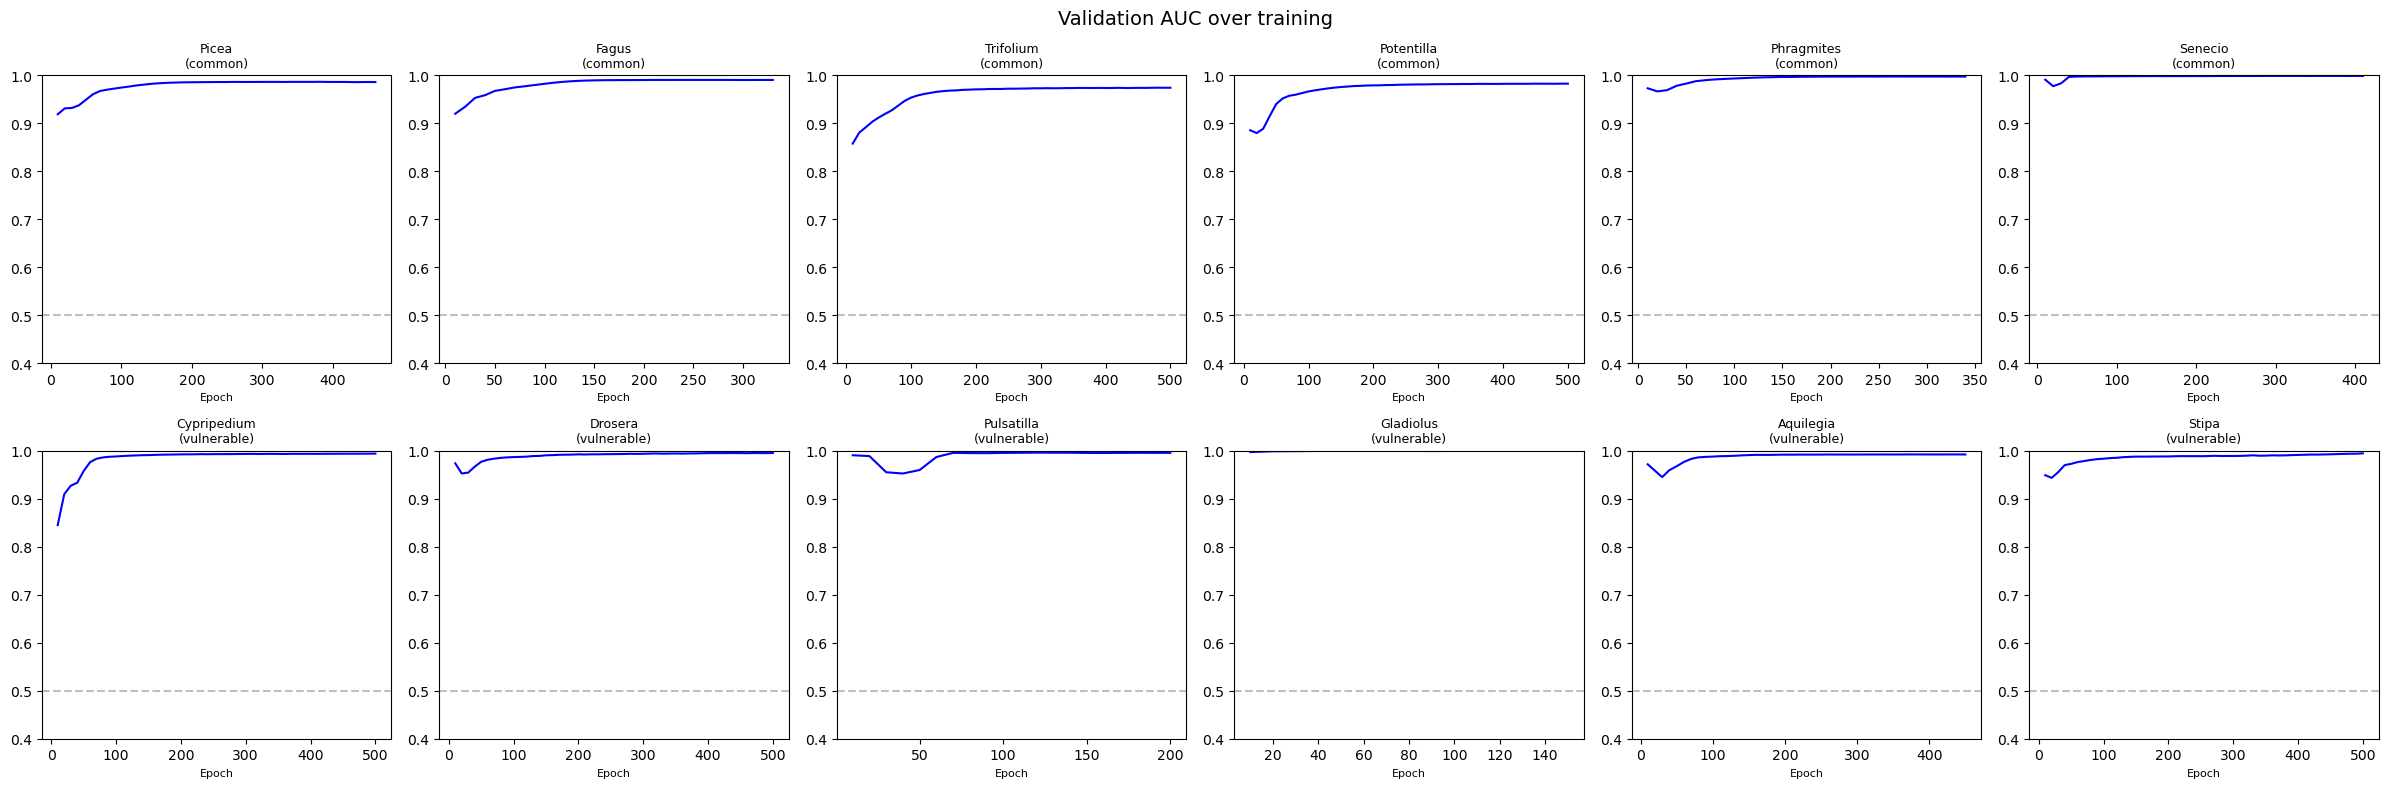

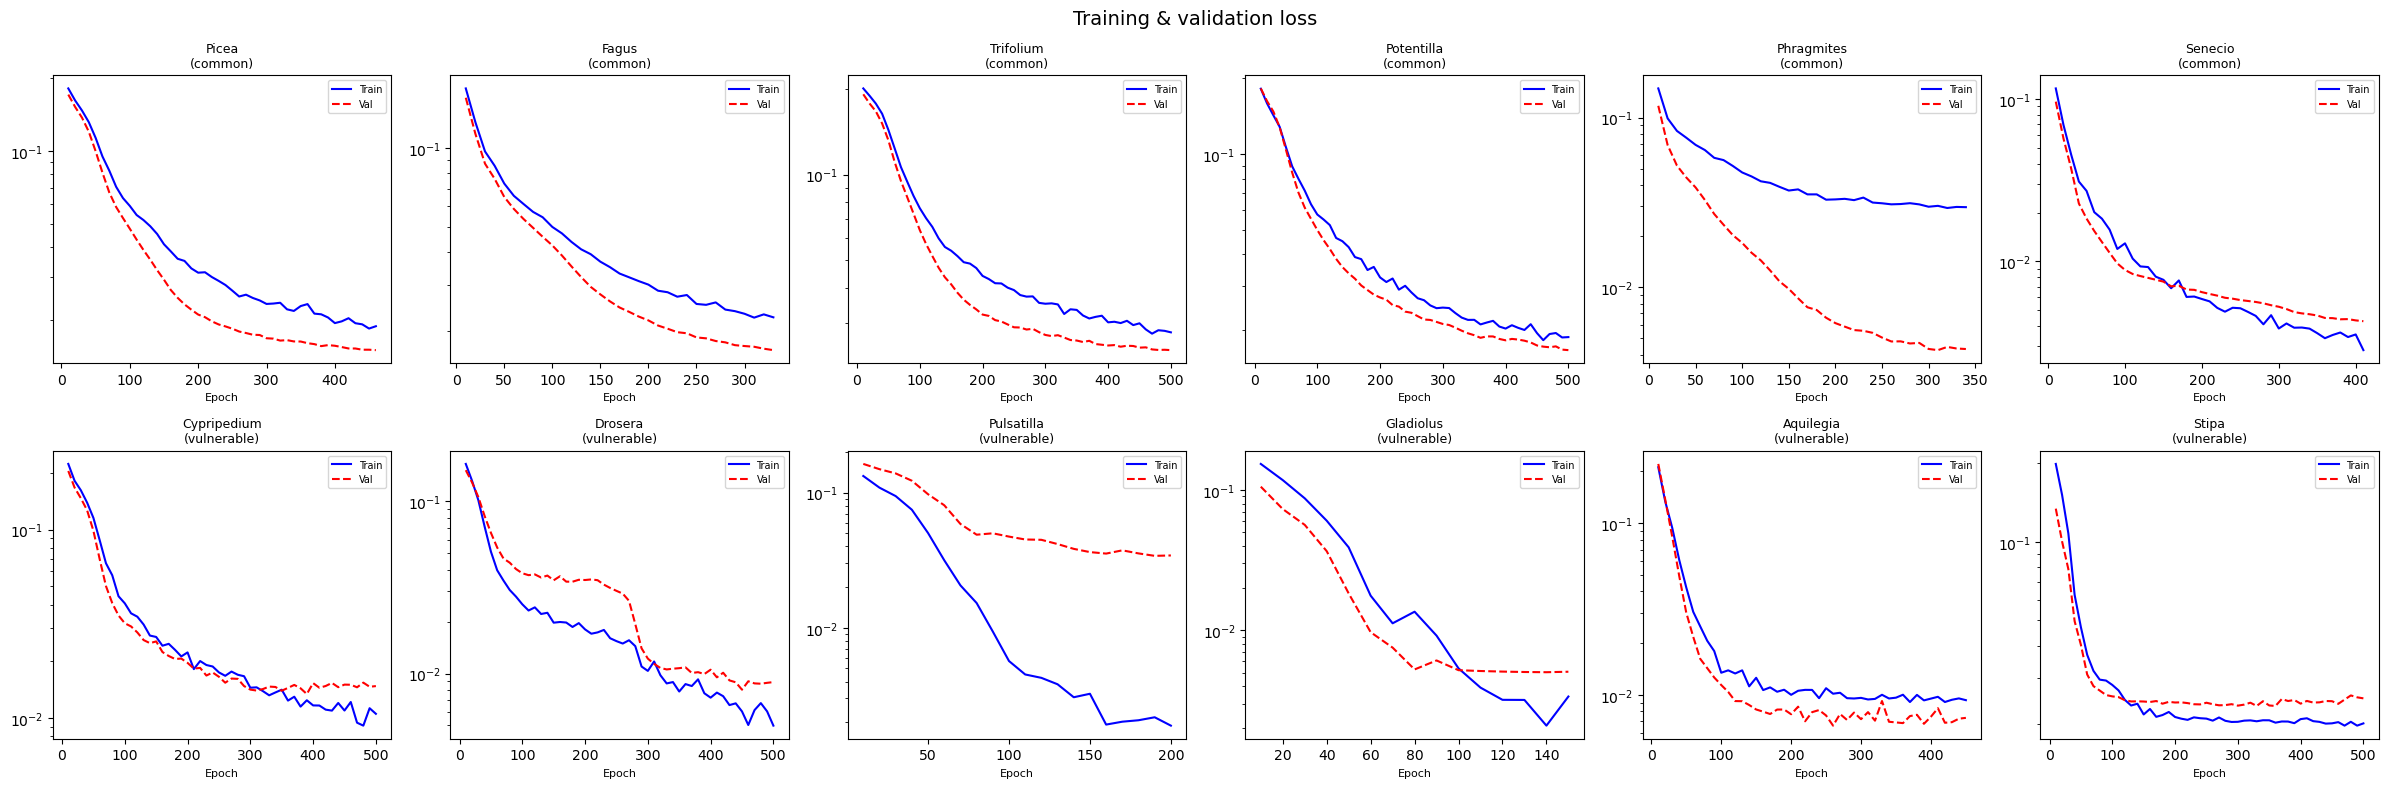

In [7]:
import matplotlib.pyplot as plt

# --- Val AUC curves ---
fig, axes = plt.subplots(2, 6, figsize=(24, 8))
for ax, sp in zip(axes.flat, ALL_SELECTED):
    hist = all_histories.get(sp)
    if hist:
        epochs = [h['epoch'] for h in hist]
        ax.plot(epochs, [h['val_auc'] for h in hist], 'b-', label='Val AUC')
        ax.set_ylim(0.4, 1.0)
        ax.axhline(0.5, color='grey', linestyle='--', alpha=0.5)
    group = 'common' if sp in COMMON_SPECIES else 'vulnerable'
    ax.set_title(f'{sp.split()[0]}\n({group})', fontsize=9)
    ax.set_xlabel('Epoch', fontsize=8)
plt.suptitle('Validation AUC over training', fontsize=14)
plt.tight_layout()
plt.show()

# --- Loss curves (train + val) ---
fig, axes = plt.subplots(2, 6, figsize=(24, 8))
for ax, sp in zip(axes.flat, ALL_SELECTED):
    hist = all_histories.get(sp)
    if hist:
        epochs = [h['epoch'] for h in hist]
        ax.plot(epochs, [h['train_loss'] for h in hist], 'b-', label='Train')
        ax.plot(epochs, [h.get('val_loss', 0) for h in hist], 'r--', label='Val')
        ax.set_yscale('log')
        ax.legend(fontsize=7)
    group = 'common' if sp in COMMON_SPECIES else 'vulnerable'
    ax.set_title(f'{sp.split()[0]}\n({group})', fontsize=9)
    ax.set_xlabel('Epoch', fontsize=8)
plt.suptitle('Training & validation loss', fontsize=14)
plt.tight_layout()
plt.show()


### Results summary

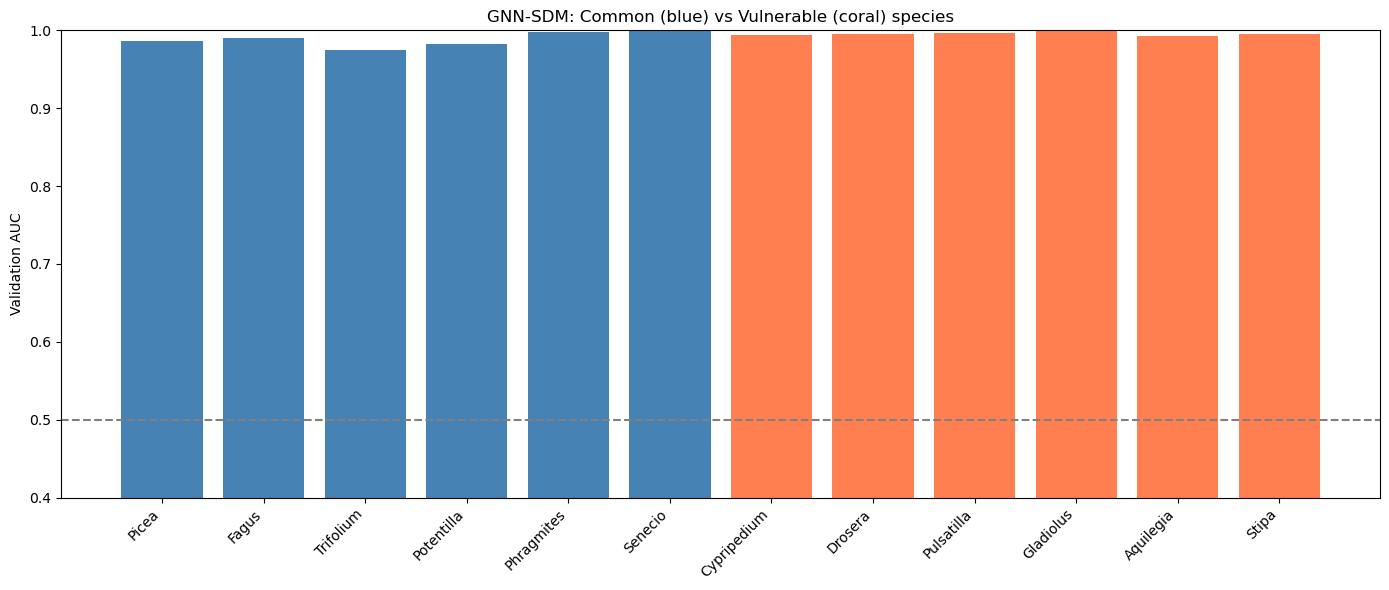

              species      group  n_patches  val_auc  epochs_trained  train_time
          Picea abies     common       7526 0.986507             460   22.485214
      Fagus sylvatica     common      14305 0.990454             330   24.404480
   Trifolium pratense     common       7383 0.974270             500   23.291736
    Potentilla erecta     common       5527 0.982703             500   21.528643
 Phragmites australis     common       3662 0.997533             340   14.631934
  Senecio inaequidens     common       4838 0.998837             410   17.948825
Cypripedium calceolus vulnerable       2423 0.994234             500   19.235674
 Drosera rotundifolia vulnerable       1499 0.995454             500   18.245963
  Pulsatilla vulgaris vulnerable        550 0.996205             200    7.305654
  Gladiolus palustris vulnerable        329 0.999880             150    5.462694
     Aquilegia alpina vulnerable        679 0.992537             450   15.816883
        Stipa pennata vulner

In [8]:
# Bar chart: common vs vulnerable
fig, ax = plt.subplots(figsize=(14, 6))
colors = ['steelblue' if g == 'common' else 'coral' for g in res_df['group']]
x = range(len(res_df))
ax.bar(x, res_df['val_auc'], color=colors)
ax.set_xticks(x)
ax.set_xticklabels([s.split()[0] for s in res_df['species']],
                   rotation=45, ha='right')
ax.set_ylabel('Validation AUC')
ax.set_title('GNN-SDM: Common (blue) vs Vulnerable (coral) species')
ax.axhline(0.5, color='grey', linestyle='--')
ax.set_ylim(0.4, 1.0)
plt.tight_layout()
plt.show()

print(res_df.to_string(index=False))
print(f'\nCommon mean AUC:     {res_df[res_df["group"]=="common"]["val_auc"].mean():.3f}')
print(f'Vulnerable mean AUC: {res_df[res_df["group"]=="vulnerable"]["val_auc"].mean():.3f}')

res_df.to_csv('gnn_selected_species_results.csv', index=False)
print('\nSaved gnn_selected_species_results.csv')
